In [1]:
import os
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rioxarray as rio
import geopandas as gpd

In [2]:
sRenalysisT = '/g100_work/IscrC_IT-WATER/data_CMCC/reanalysis/T'
sRcp45T = '/g100_work/IscrC_IT-WATER/data_CMCC/rcp45/T'
sRcp85T = '/g100_work/IscrC_IT-WATER/data_CMCC/rcp85/T'

In [13]:
asRenalysisT = os.listdir(sRenalysisT)
asRenalysisT.sort()

In [17]:
for sYearFolder in asRenalysisT:
    aoDailyMean = []
    sYearPath = sRenalysisT+'/'+sYearFolder
    asNcRenalysisT = os.listdir(sYearPath)
    for sNcRenalysisT in asNcRenalysisT:
        xrTemperature = xr.open_dataset(sYearPath+'/'+sNcRenalysisT, engine="netcdf4")
        xrDailyMean = xrTemperature.Tair.mean(dim=['nt'])
        aoDailyMean.append(xrDailyMean)
    oResultDailyMean = sum(aoDailyMean) / len(aoDailyMean)
    oResultDailyMean.to_netcdf("./results_temperature/results_daily_mean_"+sYearFolder+".nc")

In [18]:
asRcp45T = os.listdir(sRcp45T)
asRcp45T.sort()

In [20]:
for sYearFolder in asRcp45T:
    aoDailyMean = []
    sYearPath = sRcp45T+'/'+sYearFolder
    asNcRcp45T = os.listdir(sYearPath)
    for sNcRcp45T in asNcRcp45T:
        xrTemperature = xr.open_dataset(sYearPath+'/'+sNcRcp45T, engine="netcdf4")
        xrDailyMean = xrTemperature.Tair.mean(dim=['nt'])
        aoDailyMean.append(xrDailyMean)
    oResultDailyMean = sum(aoDailyMean) / len(aoDailyMean)
    oResultDailyMean.to_netcdf("./results_temperature/rcp45/results_daily_mean_rcp45_"+sYearFolder+".nc")

In [3]:
asRcp85T = os.listdir(sRcp85T)
asRcp85T.sort()

In [5]:
for sYearFolder in asRcp85T:
    aoDailyMean = []
    sYearPath = sRcp85T+'/'+sYearFolder
    asNcRcp85T = os.listdir(sYearPath)
    for sNcRcp85T in asNcRcp85T:
        xrTemperature = xr.open_dataset(sYearPath+'/'+sNcRcp85T, engine="netcdf4")
        xrDailyMean = xrTemperature.Tair.mean(dim=['nt'])
        aoDailyMean.append(xrDailyMean)
    oResultDailyMean = sum(aoDailyMean) / len(aoDailyMean)
    oResultDailyMean.to_netcdf("./results_temperature/rcp85/results_daily_mean_rcp85_"+sYearFolder+".nc")

In [3]:
sRcp85ForMeanT = './results_temperature/rcp85/'
sRcp45ForMeanT = './results_temperature/rcp45/'
sReanalysisForMeanT = './results_temperature/reanalysis/'

In [4]:
asRcp85ForMeanT = os.listdir(sRcp85ForMeanT)
asRcp85ForMeanT.sort()

In [7]:
aoYearlyMeanRcp85 = []
for sFileRcp85 in asRcp85ForMeanT:
    if '.nc' in sFileRcp85:
        xrYearlyMeanRcp85 = xr.open_dataset(sRcp85ForMeanT+'/'+sFileRcp85, engine="netcdf4")
        aoYearlyMeanRcp85.append(xrYearlyMeanRcp85)

In [8]:
oResultYearlyMeanRcp85 = sum(aoYearlyMeanRcp85) / len(aoYearlyMeanRcp85)
oResultYearlyMeanRcp85.to_netcdf("./results_temperature/rcp85/yearly_mean/results_yearly_mean_rcp85.nc")

In [9]:
asRcp45ForMeanT = os.listdir(sRcp45ForMeanT)
asRcp45ForMeanT.sort()

In [10]:
aoYearlyMeanRcp45 = []
for sFileRcp45 in asRcp45ForMeanT:
    if '.nc' in sFileRcp45:
        xrYearlyMeanRcp45 = xr.open_dataset(sRcp45ForMeanT+'/'+sFileRcp45, engine="netcdf4")
        aoYearlyMeanRcp45.append(xrYearlyMeanRcp45)

In [11]:
oResultYearlyMeanRcp45 = sum(aoYearlyMeanRcp45) / len(aoYearlyMeanRcp45)
oResultYearlyMeanRcp45.to_netcdf("./results_temperature/rcp45/yearly_mean/results_yearly_mean_rcp45.nc")

In [12]:
asReanalysisForMeanT = os.listdir(sReanalysisForMeanT)
asReanalysisForMeanT.sort()

In [13]:
aoYearlyMeanReanalysis = []
for sFileReanalysis in asReanalysisForMeanT:
    if '.nc' in sFileReanalysis:
        xrYearlyMeanReanalysis = xr.open_dataset(sReanalysisForMeanT+'/'+sFileReanalysis, engine="netcdf4")
        aoYearlyMeanReanalysis.append(xrYearlyMeanReanalysis)

In [14]:
oResultYearlyMeanReanalysis = sum(aoYearlyMeanReanalysis) / len(aoYearlyMeanReanalysis)
oResultYearlyMeanReanalysis.to_netcdf("./results_temperature/reanalysis/yearly_mean/results_yearly_mean_reanalysis.nc")

In [15]:
oYearlyRcp85 = xr.open_dataset("./results_temperature/rcp85/yearly_mean/results_yearly_mean_rcp85.nc", engine="netcdf4")
oYearlyRcp45 = xr.open_dataset("./results_temperature/rcp45/yearly_mean/results_yearly_mean_rcp45.nc", engine="netcdf4")
oYearlyReanalysis = xr.open_dataset("./results_temperature/reanalysis/yearly_mean/results_yearly_mean_reanalysis.nc", engine="netcdf4")

In [16]:
oRcp85Reanalysis = oYearlyRcp85 - oYearlyReanalysis

In [17]:
oRcp45Reanalysis = oYearlyRcp45 - oYearlyReanalysis

In [18]:
oRcp85Reanalysis.to_netcdf("./results_temperature/final_results/rcp85Reanalysis.nc")
oRcp45Reanalysis.to_netcdf("./results_temperature/final_results/rcp45Reanalysis.nc")

In [2]:
oRcp85Reanalysis = xr.open_dataset("./results_temperature/final_results/rcp85Reanalysis.nc", engine="netcdf4")

In [3]:
shapefile_path = r'ITA_adm1.shp'
gdf = gpd.read_file(shapefile_path)

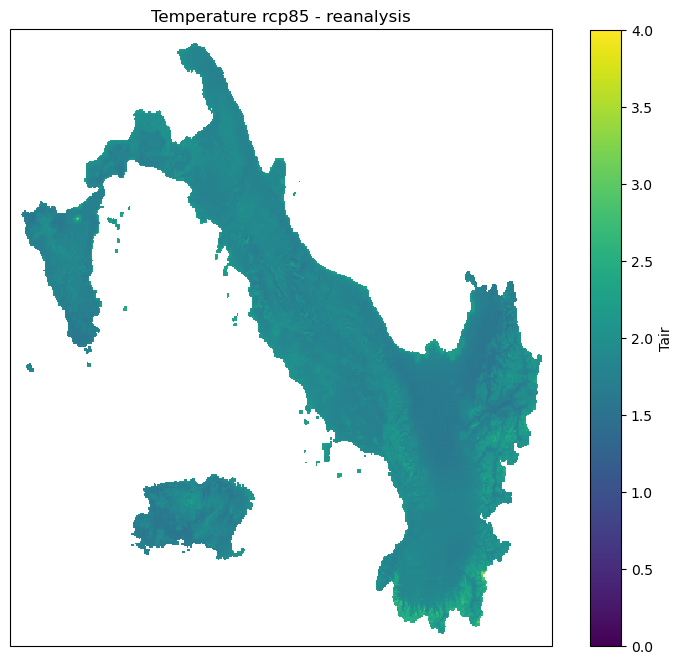

In [14]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp85Reanalysis['Tair'].plot.pcolormesh(ax=ax, cmap='viridis', vmin=0, vmax=4, transform=ccrs.PlateCarree())
ax.set_title('Temperature rcp85 - reanalysis')
plt.show()

In [15]:
oRcp45Reanalysis = xr.open_dataset("./results_temperature/final_results/rcp45Reanalysis.nc", engine="netcdf4")

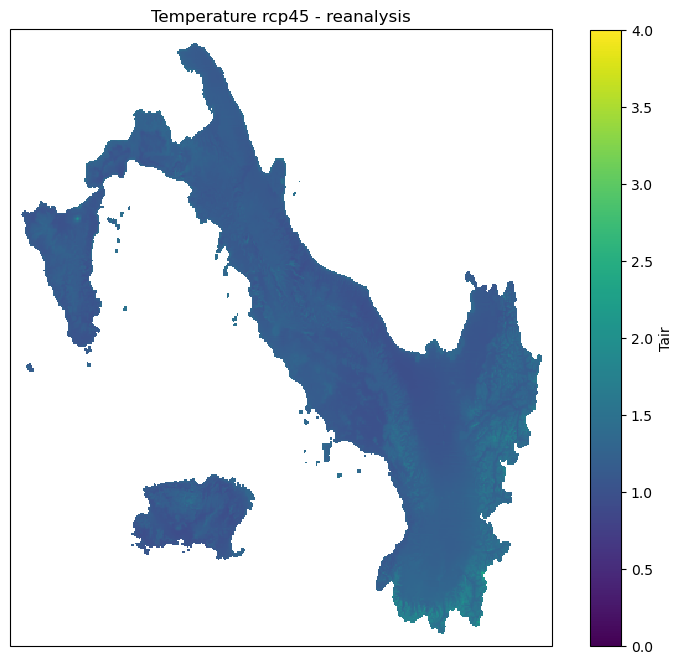

In [16]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp45Reanalysis['Tair'].plot.pcolormesh(ax=ax, cmap='viridis', vmin=0, vmax=4, transform=ccrs.PlateCarree())
ax.set_title('Temperature rcp45 - reanalysis')
plt.show()

In [17]:
gdf

,ID_0,ISO,NAME_0,ID_1,NAME_1,TYPE_1,ENGTYPE_1,NL_NAME_1,VARNAME_1,geometry
0,112,ITA,Italy,1,Abruzzo,Regione,Region,None,Abruzos|Abruzzen|Abruzzes|Abruzzi,"POLYGON ((13.91542 42.89561, 13.91542 42.89542..."
1,112,ITA,Italy,2,Apulia,Regione,Region,None,Apulien|Pouilles|Pouille|Puglia|Puglie,"MULTIPOLYGON (((17.94931 40.05375, 17.94931 40..."
2,112,ITA,Italy,3,Basilicata,Regione,Region,None,Basilicate|Lucania,"MULTIPOLYGON (((15.71736 39.96792, 15.71736 39..."
3,112,ITA,Italy,4,Calabria,Regione,Region,None,Calabre|Calabrie|Kalabrien,"MULTIPOLYGON (((15.80208 39.70014, 15.80208 39..."
4,112,ITA,Italy,5,Campania,Regione,Region,None,Campanha|Campanie|Kampanien,"MULTIPOLYGON (((14.25264 40.54153, 14.25264 40..."
5,112,ITA,Italy,6,Emilia-Romagna,Regione,Region,None,Emilia Romagna|Emilia|Emilia-Romaña|Émilie-Rom...,"MULTIPOLYGON (((12.4059 43.89975, 12.406 43.89..."
6,112,ITA,Italy,7,Friuli-Venezia Giulia,Regione,Autonomous Region,None,Friuli Venezia Giulia|Friuli-Venecia Julia,"MULTIPOLYGON (((13.31625 45.69347, 13.31625 45..."
7,112,ITA,Italy,8,Lazio,Regione,Region,None,Lacio|Latium,"MULTIPOLYGON (((13.45514 40.79264, 13.45514 40..."
8,112,ITA,Italy,9,Liguria,Regione,Region,None,Ligurie|Ligurien,"MULTIPOLYGON (((8.22597 44.02736, 8.22597 44.0..."
9,112,ITA,Italy,10,Lombardia,Regione,Region,None,Lombardy|Lombardei|Lombardie,"MULTIPOLYGON (((8.81457 45.01818, 8.81401 45.0..."


In [18]:
oSardegna = gdf[gdf['NAME_1'] == 'Sardegna']
oSardegna

,ID_0,ISO,NAME_0,ID_1,NAME_1,TYPE_1,ENGTYPE_1,NL_NAME_1,VARNAME_1,geometry
13,112,ITA,Italy,14,Sardegna,Regione,Autonomous Region,None,Cerdeña|Sardenha,"MULTIPOLYGON (((8.4107 38.86319, 8.4107 38.862..."


In [19]:
oSardegna = oSardegna.reset_index(drop=True)
oSardegna

,ID_0,ISO,NAME_0,ID_1,NAME_1,TYPE_1,ENGTYPE_1,NL_NAME_1,VARNAME_1,geometry
0,112,ITA,Italy,14,Sardegna,Regione,Autonomous Region,None,Cerdeña|Sardenha,"MULTIPOLYGON (((8.4107 38.86319, 8.4107 38.862..."


In [21]:
dataRcp45Reanalysis = oRcp45Reanalysis.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
dataRcp45Reanalysis = oRcp45Reanalysis.rio.write_crs("epsg:4326", inplace=True)

In [22]:
oSardegna = oSardegna.to_crs(dataRcp45Reanalysis.rio.crs)

In [23]:
oSardegnaGeometries = oSardegna.geometry

In [24]:
oClippedData = dataRcp45Reanalysis.rio.clip(oSardegnaGeometries, oSardegna.crs)

In [25]:
output_path = r'./results_temperature/final_results/rcp45ReanalysisSardegna.nc'
oClippedData.to_netcdf(output_path)

In [26]:
oRcp45ReanalysisSardegna = xr.open_dataset("./results_temperature/final_results/rcp45ReanalysisSardegna.nc", engine="netcdf4")

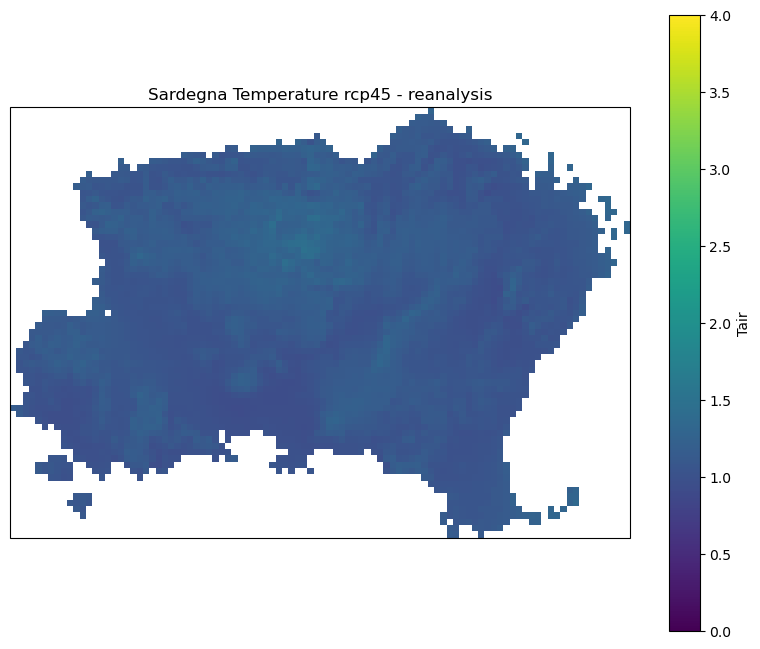

In [27]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp45ReanalysisSardegna['Tair'].plot.pcolormesh(ax=ax, cmap='viridis', vmin=0, vmax=4, transform=ccrs.PlateCarree())
ax.set_title('Sardegna Temperature rcp45 - reanalysis')
plt.show()

In [28]:
dataRcp85Reanalysis = oRcp85Reanalysis.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
dataRcp85Reanalysis = oRcp85Reanalysis.rio.write_crs("epsg:4326", inplace=True)

In [29]:
oClippedDataRcp85 = dataRcp85Reanalysis.rio.clip(oSardegnaGeometries, oSardegna.crs)

In [30]:
output_path_85 = r'./results_temperature/final_results/rcp85ReanalysisSardegna.nc'
oClippedDataRcp85.to_netcdf(output_path_85)

In [31]:
oRcp85ReanalysisSardegna = xr.open_dataset("./results_temperature/final_results/rcp85ReanalysisSardegna.nc", engine="netcdf4")

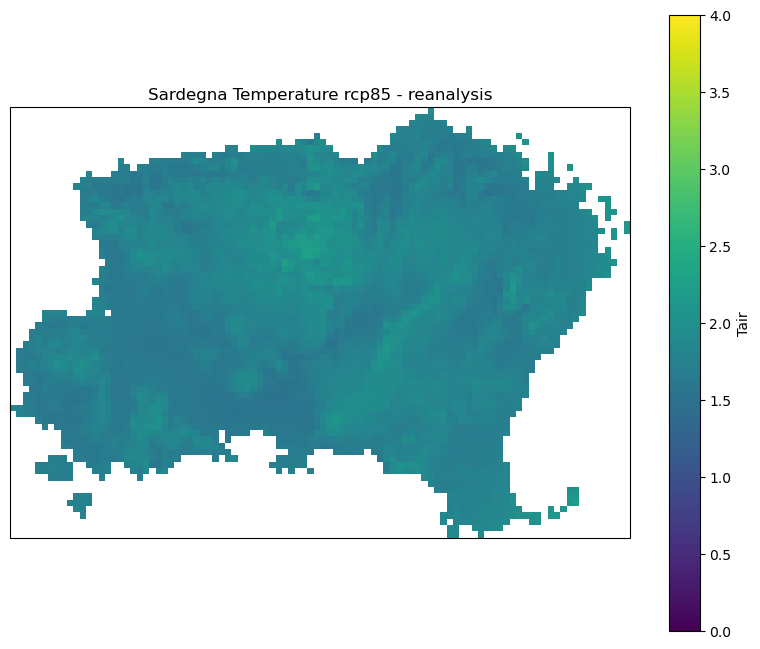

In [32]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
pc = oRcp85ReanalysisSardegna['Tair'].plot.pcolormesh(ax=ax, cmap='viridis', vmin=0, vmax=4, transform=ccrs.PlateCarree())
ax.set_title('Sardegna Temperature rcp85 - reanalysis')
plt.show()